# Function 6

<b> Description of the Sample Application:</b> You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sums



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |


## Progress Log

| Week | Query Point (x) | Output (y) | Acquisition / β | Notes |
|---|---|---|---|---|
|  |  |  |  |  |
| Week 1 | 0.409594-0.023713-0.771229-0.966490-0.130973 | **-0.710675** | UCB, β = 2.5 (high exploration) | Slight improvement over the initial best (-0.714265); high β used deliberately since only 20 points were available in 5D |
| Week 2 | |  | UCB, β = 2.0 (moderate exploration) | Lowering β per Week 1 reflection: shift gradually toward exploitation as data accumulates |

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.optimize import minimize

from plotting_utils import plot_convergence, plot_parallel_coordinates

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [12]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)


# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.409594, 0.023713, 0.771229, 0.96649 , 0.130973 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.710675183457194]                                  , dtype = np.float64)    # from output.txt

# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point))
Y_updated      = np.append(Y0, Y_w1_new_point)

#print(X_updated)
#print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

In [16]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"y Range: [: {Y.min()}, {Y.max()}]")
best_idx        = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
ingredient_names = ["flour", "sugar", "eggs", "butter", "milk"]
df               = pd.DataFrame(X, columns = [ingredient_names])
df['Y']          = Y
print("Data Frame:\n", df)

Input  Shape: (21, 5)
Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.7049

# Data Exploration

In [19]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
            flour      sugar       eggs     butter       milk          Y
count  21.000000  21.000000  21.000000  21.000000  21.000000  21.000000
mean    0.541186   0.536910   0.481693   0.555007   0.409804  -1.458023
std     0.296877   0.300406   0.314387   0.288976   0.296635   0.480545
min     0.021735   0.023713   0.016523   0.045613   0.004911  -2.571170
25%     0.258906   0.291470   0.187288   0.356552   0.112433  -1.702558
50%     0.618812   0.536336   0.443284   0.648324   0.501953  -1.356682
75%     0.770620   0.803484   0.732552   0.726272   0.614962  -1.209955
max     0.957740   0.931871   0.978806   0.966490   0.892819  -0.710675


In [21]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 flour     0
sugar     0
eggs      0
butter    0
milk      0
Y         0
dtype: int64


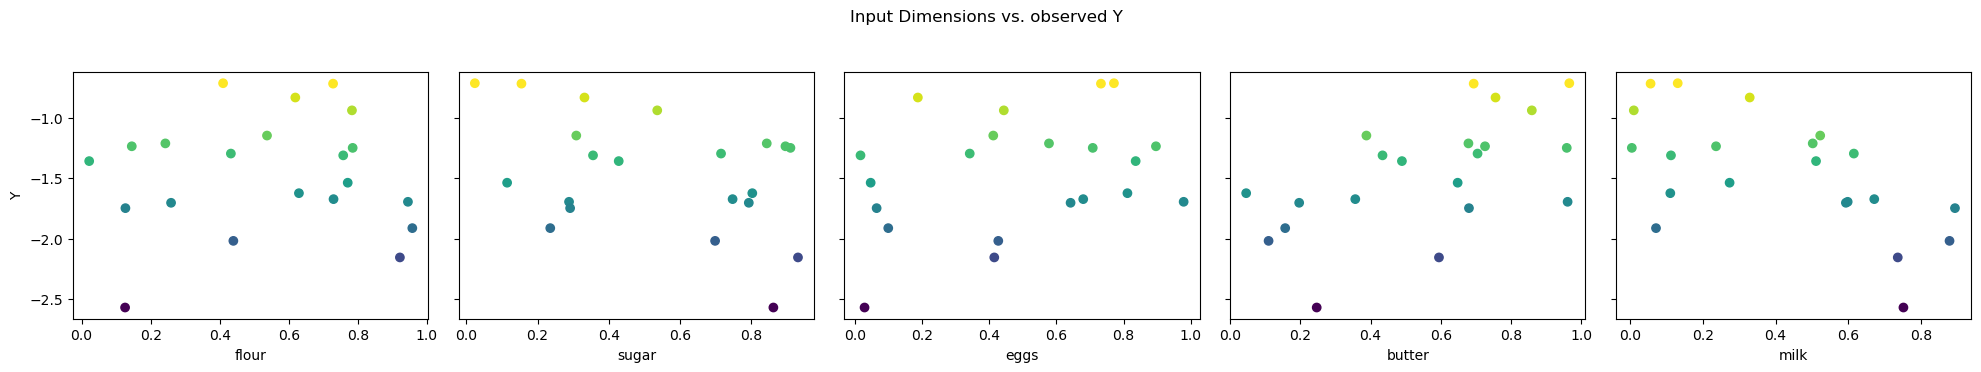

In [25]:
# Pairwise Scatter Plot, showing relationship of y for each input
fig, axes = plt.subplots(1, len(ingredient_names), figsize = (4 * len(ingredient_names), 3.5), sharey = True)
for ax, col in zip(axes, ingredient_names):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = 'viridis')
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

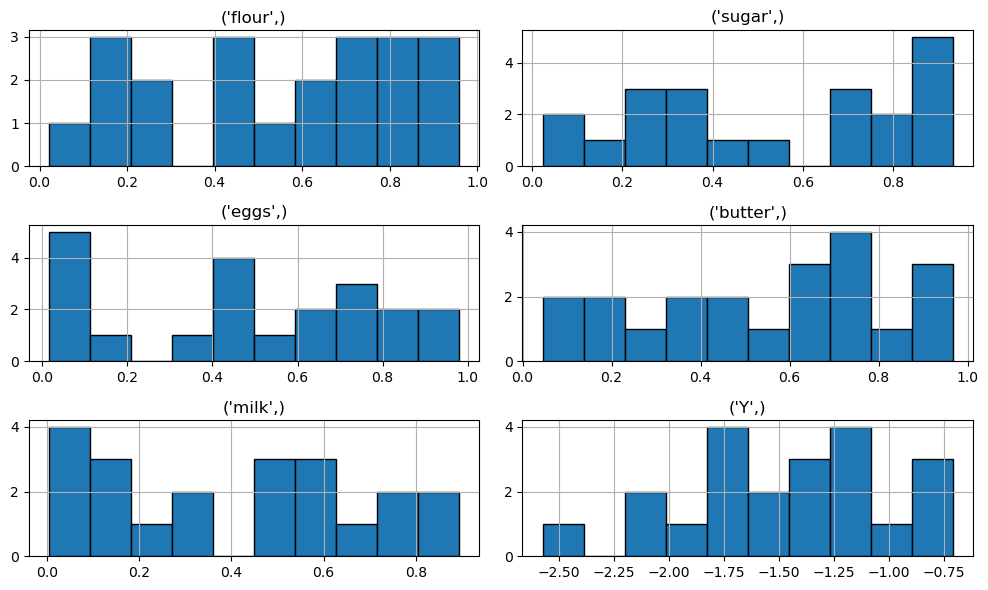

In [27]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [29]:
# Understanding Correlation between each input with y
print("Correlation of each input with y:\n")

for i, lab in enumerate(ingredient_names):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(flour, Y) = 0.05249328153618924
 corr(sugar, Y) = -0.4235987611288335
 corr(eggs, Y) = 0.3114020260043079
 corr(butter, Y) = 0.5830167715778206
 corr(milk, Y) = -0.6096212468642637


<Axes: xlabel='None', ylabel='None'>

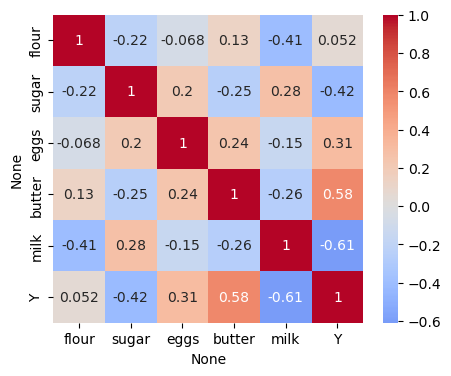

In [31]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

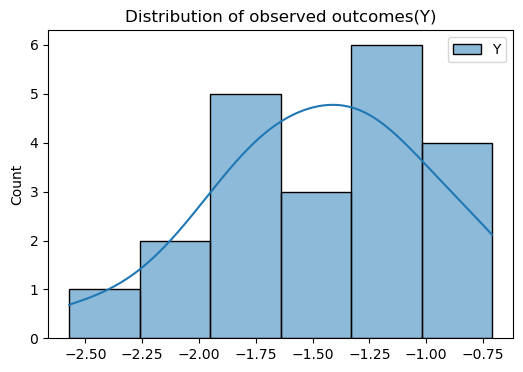

In [35]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [135]:
# Define the kernel and initialise the GP model
n, d       = X.shape
kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * d, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [140]:
# Train the model

gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.76**2 * RBF(length_scale=[0.814, 4.86, 4.83, 3.73, 5.37]) + WhiteKernel(noise_level=0.0251)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [144]:
# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (10000, d))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.40959444 0.02371308 0.77122945 0.96648988 0.1309728 ]
UCB Score: 5.596167e-01


# Week 2: Define a consolidated Bayesian Function 
1. Fit a GP surrogate (ARD-RBF + white noise) on all data so far
2. Optimise the UCB acquisition function with multi-start **L-BFGS-B**
3. Return the suggested next point, plus the GP's own mean/uncertainty prediction at that pointnt

In [50]:
# For Week - 2, decreasing the value of beta
beta         = 2.0

def suggest_next_bo_point(X, Y, beta, n_restarts = 20, seed = 42):

    n_dims = X.shape[1]

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * n_dims, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
    
    gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std = True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        # scipy.optimize.minimize only minimises, so we minimise -UCB to maximise UCB
        x      = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    rng        = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    bounds     = [(0.0, 0.999999)] * n_dims

    for x0 in rng.uniform(0.0, 0.999999, size = (n_restarts, n_dims)):
        res    = minimize(neg_ucb, x0, args = (gpr, beta), bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x   = res.x

    next_x = np.clip(best_x, 0.0, 0.999999,)
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std = True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0]


In [62]:
next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta = beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 2 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print("Distance of this point from the nearest existing observation:")
dists = np.linalg.norm(X - next_x, axis = 1)
print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")

Learned kernel: 2.61**2 * RBF(length_scale=[0.817, 7.65, 5.44, 3.78, 5.37]) + WhiteKernel(noise_level=0.0424)

Week 2 suggested query point   :  [0.40876803 0.         0.999999   0.999999   0.        ]
GP predicted mean at this point:  -0.296469
GP predicted std  at this point:  0.266899
UCB value                      :  0.237329

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.2668  (0 would mean re-querying an existing point)


# Week 2: Visualisation

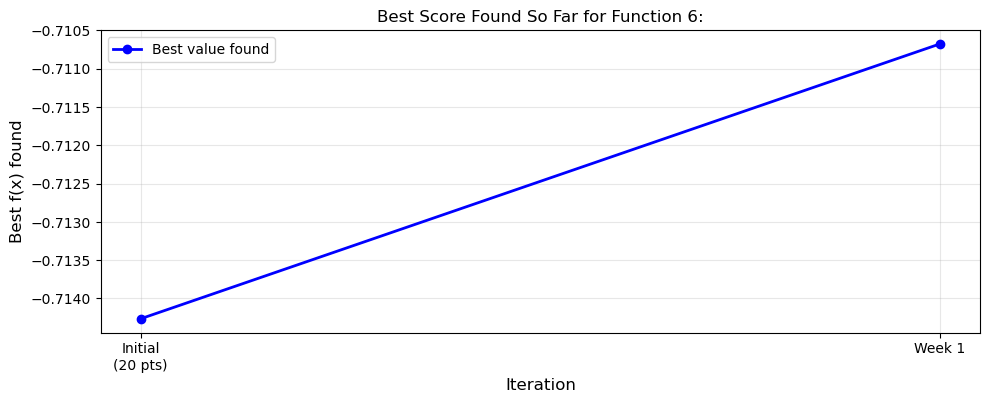

In [65]:
# Convergence: best value found so far, round by round
best_so_far  = [ np.max(Y[:20]),   # best among the original 20 points
                 np.max(Y[:21]),   # best after Week 1's point was appended
               ]

round_labels = ["Initial\n(20 pts)", "Week 1"]

fig, ax      = plot_convergence(range(len(best_so_far)), best_so_far)

ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6:")
plt.show()


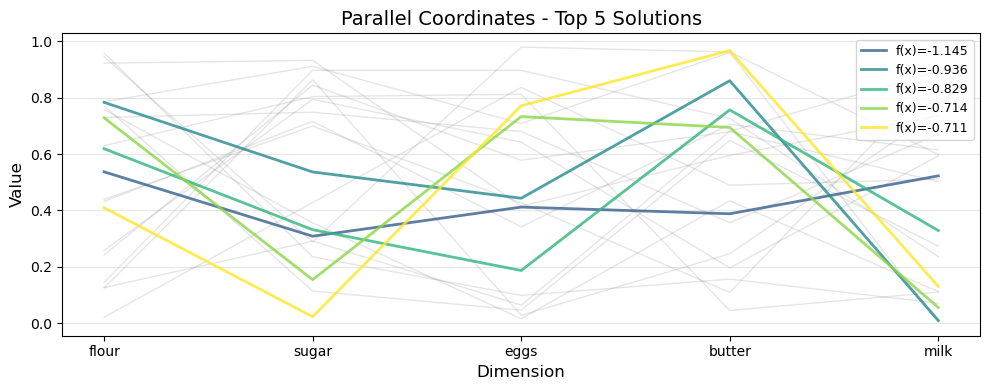

In [67]:
# Parallel coordinates: see all 5 ingredients at once, highlighting the top samples
fig, ax = plot_parallel_coordinates(X, Y, n_best = 5)
ax.set_xticklabels(ingredient_names)
plt.show()

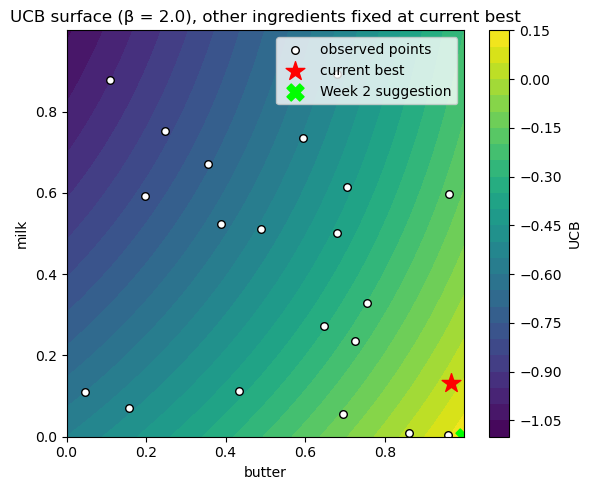

In [73]:
# UCB surface as a 2D slice through the current best point (5D can't be plotted directly, so we fix 3 ingredients at the current best
#  and sweep 2 of them on a grid)

def ucb(X_query, gpr, beta):
    mu, sigma   = gpr.predict(X_query, return_std = True)
    return mu + beta * sigma

x_best = X[np.argmax(Y)]
dim_a, dim_b    = 3, 4  # butter vs milk
resolution      = 60
grid            = np.linspace(0.0, 0.999999, resolution)
A, B            = np.meshgrid(grid, grid)

X_grid = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface      = ucb(X_grid, gpr, beta = 2.0).reshape(resolution, resolution)

plt.figure(figsize = (6, 5))
cf = plt.contourf(A, B, ucb_surface, levels = 25, cmap = "viridis")
plt.colorbar(cf, label = "UCB")
plt.scatter(X[:, dim_a], X[:, dim_b], c = "white", edgecolor = "black", s = 30, label = "observed points")
plt.scatter(x_best[dim_a], x_best[dim_b], c = "red", marker = "*", s = 200, label = "current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c = "lime", marker = "X", s = 150, label = "Week 2 suggestion")
plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (β = {beta}), other ingredients fixed at current best")
plt.legend()
plt.tight_layout()
plt.show()

# Portal Submission 

In [60]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_x)
print(f"Points to be submitted(Week 1):\n{submission_str}")

Points to be submitted(Week 1):
0.408768-0.000000-0.999999-0.999999-0.000000
